---
**Pipeline:** [01 Dataset] → **[02 Architecture]** → [03 Optimization] → [04 Training] → [05 Evaluation] → [06 Export]

**Prev:** `01_dataset_download.ipynb` | **Next:** `03_training_optimization.ipynb`

---

# 🏗️ 02 - Model Architecture

## MobileFaceNet + ArcFace Deep Dive

This notebook explains the model architecture in detail.

**Contents:**
- 📐 MobileFaceNet backbone
- 🎯 ArcFace loss function
- 📊 Architecture visualization
- 🔬 Parameter analysis

---

## 1. Environment Setup

In [10]:
# Environment detection
import os
import sys
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
    print("🌐 Running in Google Colab")
    PROJECT_ROOT = Path("/content/face_recognition")
    drive.mount('/content/drive')
    DRIVE_ROOT = Path("/content/drive/MyDrive/face_based_attendance_system")
    print(f"⚡ Data: {PROJECT_ROOT}")
    print(f"💾 Models: {DRIVE_ROOT}")
except ImportError:
    IN_COLAB = False
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
    DRIVE_ROOT = None
    print("💻 Running locally")

sys.path.insert(0, str(PROJECT_ROOT))
print(f"📂 Project root: {PROJECT_ROOT}")

🌐 Running in Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚡ Data: /content/face_recognition
💾 Models: /content/drive/MyDrive/face_based_attendance_system
📂 Project root: /content/face_recognition


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔧 Using device: {device}")

🔧 Using device: cuda


## 2. MobileFaceNet Architecture

MobileFaceNet is a lightweight face recognition backbone optimized for mobile/edge devices.

### Key Features:
- **~1M parameters** (vs 25M+ for ResNet-50)
- **Depthwise Separable Convolutions** for efficiency
- **Linear Bottleneck** structure
- **112x112 input** → **512-D embedding**

In [12]:
class ConvBlock(nn.Module):
    """
    Standard Convolution Block: Conv2D -> BatchNorm -> PReLU

    This is the fundamental building block used throughout MobileFaceNet.
    PReLU is used instead of ReLU for better face representation learning.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, groups=1):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size, stride, padding, groups=groups, bias=False
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.act = nn.PReLU(out_channels)

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

print("✅ ConvBlock defined")
print("   Structure: Conv2D → BatchNorm → PReLU")

✅ ConvBlock defined
   Structure: Conv2D → BatchNorm → PReLU


In [13]:
class DepthWise(nn.Module):
    """
    Depthwise Separable Convolution Block.

    Splits a standard convolution into:
    1. Depthwise: Applies a single filter per input channel
    2. Pointwise: 1x1 convolution to combine channels

    This reduces parameters from:
    - Standard: K×K×C_in×C_out
    - Depthwise: K×K×C_in + C_in×C_out

    For 3x3 kernels, this is ~8-9x fewer parameters!
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        # Depthwise: each channel filtered separately
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, 3, stride, 1, groups=in_channels, bias=False
        )
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.act1 = nn.PReLU(in_channels)

        # Pointwise: combine channels
        self.pointwise = nn.Conv2d(in_channels, out_channels, 1, 1, 0, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.act2 = nn.PReLU(out_channels)

    def forward(self, x):
        x = self.act1(self.bn1(self.depthwise(x)))
        x = self.act2(self.bn2(self.pointwise(x)))
        return x

print("✅ DepthWise Separable block defined")
print("   Depthwise: 3x3 conv per channel")
print("   Pointwise: 1x1 to mix channels")

✅ DepthWise Separable block defined
   Depthwise: 3x3 conv per channel
   Pointwise: 1x1 to mix channels


In [14]:
class DepthWiseResidual(nn.Module):
    """
    Depthwise Separable Convolution with Residual Connection.

    When stride=1 and in_channels=out_channels:
        output = input + DepthWise(input)

    This helps with gradient flow and allows building very deep networks.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.use_residual = (stride == 1 and in_channels == out_channels)
        self.depthwise = DepthWise(in_channels, out_channels, stride)

    def forward(self, x):
        if self.use_residual:
            return x + self.depthwise(x)
        return self.depthwise(x)

print("✅ DepthWiseResidual block defined")
print("   Adds residual connection when dimensions match")

✅ DepthWiseResidual block defined
   Adds residual connection when dimensions match


In [15]:
def make_stage(in_channels, out_channels, num_blocks, stride=2):
    """
    Create a stage of depthwise residual blocks.

    First block downsamples (if stride > 1), rest maintain size.
    """
    layers = [DepthWiseResidual(in_channels, out_channels, stride)]
    for _ in range(1, num_blocks):
        layers.append(DepthWiseResidual(out_channels, out_channels, 1))
    return nn.Sequential(*layers)

print("✅ Stage builder defined")

✅ Stage builder defined


In [16]:
class MobileFaceNet(nn.Module):
    """
    MobileFaceNet: Lightweight Face Recognition Backbone

    Architecture:
    - Input: 112 x 112 x 3
    - Conv3x3/2 → 56x56
    - DepthWise → 56x56
    - Stage 1 (5 blocks, stride 2) → 28x28
    - Stage 2 (1 block, stride 2) → 14x14
    - Stage 3 (6 blocks, stride 2) → 7x7
    - Stage 4 (1 block, stride 1) → 7x7
    - Conv1x1 → 512 channels
    - Linear GDC → 512-D embedding

    Total: ~1M parameters
    """
    def __init__(self, embedding_dim=512):
        super().__init__()

        # Initial convolution: 112x112 → 56x56
        self.conv1 = ConvBlock(3, 64, kernel_size=3, stride=2, padding=1)

        # Depthwise conv
        self.dw1 = DepthWise(64, 64, stride=1)

        # Bottleneck stages
        self.stage1 = make_stage(64, 64, num_blocks=5, stride=2)   # → 28x28
        self.stage2 = make_stage(64, 128, num_blocks=1, stride=2)  # → 14x14
        self.stage3 = make_stage(128, 128, num_blocks=6, stride=2) # → 7x7
        self.stage4 = make_stage(128, 128, num_blocks=1, stride=1) # → 7x7

        # Head: expand channels and Global Depthwise Convolution
        self.conv_expand = ConvBlock(128, 512, kernel_size=1, stride=1, padding=0)

        # Linear GDC: 7x7 → 1x1 (global pooling with depthwise conv)
        self.gdc = nn.Sequential(
            nn.Conv2d(512, 512, 7, 1, 0, groups=512, bias=False),
            nn.BatchNorm2d(512),
        )

        # Final linear layer
        self.fc = nn.Linear(512, embedding_dim, bias=False)
        self.bn_final = nn.BatchNorm1d(embedding_dim)

        self._initialize_weights()

    def _initialize_weights(self):
        """Kaiming initialization for better convergence."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
            elif isinstance(m, nn.BatchNorm2d) or isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')

    def forward(self, x):
        x = self.conv1(x)
        x = self.dw1(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.conv_expand(x)
        x = self.gdc(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        x = self.bn_final(x)
        return F.normalize(x, p=2, dim=1)  # L2 normalize

print("✅ MobileFaceNet defined")

✅ MobileFaceNet defined


In [17]:
# Test the model
model = MobileFaceNet(embedding_dim=512)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("📊 MobileFaceNet Statistics:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")
print(f"   Model size: ~{total_params * 4 / 1024 / 1024:.1f} MB (FP32)")

# Test forward pass - set to eval mode for batch size 1
model.eval()  # Important: BatchNorm needs eval mode for batch size 1
with torch.no_grad():
    x = torch.randn(1, 3, 112, 112)
    embedding = model(x)

print(f"\n🔍 Forward pass:")
print(f"   Input shape: {x.shape}")
print(f"   Output shape: {embedding.shape}")
print(f"   Embedding norm: {embedding.norm().item():.4f} (should be ~1.0)")
print(f"\n💡 Model in eval mode for testing (BatchNorm requires >1 sample in training mode)")

📊 MobileFaceNet Statistics:
   Total parameters: 526,080
   Trainable params: 526,080
   Model size: ~2.0 MB (FP32)

🔍 Forward pass:
   Input shape: torch.Size([1, 3, 112, 112])
   Output shape: torch.Size([1, 512])
   Embedding norm: 1.0000 (should be ~1.0)

💡 Model in eval mode for testing (BatchNorm requires >1 sample in training mode)


## 3. ArcFace Loss

### Why ArcFace?

Standard softmax loss doesn't ensure separable features. ArcFace adds an **angular margin penalty** to enforce:
- Smaller intra-class variation (faces of same person closer)
- Larger inter-class variation (faces of different people farther)

### Formula:
$$L = -\frac{1}{N}\sum_{i=1}^{N}\log\frac{e^{s\cdot\cos(\theta_{y_i}+m)}}{e^{s\cdot\cos(\theta_{y_i}+m)}+\sum_{j \neq y_i}e^{s\cdot\cos\theta_j}}$$

Where:
- $s$ = scale (typically 64)
- $m$ = angular margin (typically 0.5 radians ≈ 28.6°)
- $\theta$ = angle between embedding and class weight

In [18]:
class ArcFace(nn.Module):
    """
    ArcFace: Additive Angular Margin Loss.

    Key improvements:
    - Numerically stable arccos-based margin (matches insightface official)
    - Margin warmup support via set_margin()
    - Stores raw cosine for accurate training accuracy measurement
    - FP32 forced internally for AMP stability

    Args:
        in_features: Embedding dimension (512)
        out_features: Number of classes/identities
        scale: Scaling factor (default 64)
        margin: Angular margin in radians (default 0.5)
    """
    def __init__(self, in_features, out_features, scale=64.0, margin=0.5):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.scale = scale
        self.margin = margin

        # Weight matrix: each column is a class center
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)
        self._last_cos = None  # Store raw cosine for accuracy computation

    def set_margin(self, m):
        """Dynamically update margin (for margin warmup)."""
        self.margin = m

    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: [batch, 512] L2-normalized
            labels: [batch] class labels

        Returns:
            Scaled logits with angular margin applied
        """
        # ✅ Force FP32 for numerical stability under AMP
        emb_fp32 = embeddings.float()
        weight_norm = F.normalize(self.weight.float(), p=2, dim=1)

        # Cosine similarity = dot product of normalized vectors
        cos_theta = F.linear(emb_fp32, weight_norm)
        cos_theta = cos_theta.clamp(-1.0 + 1e-7, 1.0 - 1e-7)

        # Store raw cosine for accuracy measurement (before margin)
        self._last_cos = cos_theta.detach()

        # ✅ Numerically stable: arccos → add margin → cos
        # This avoids sqrt(1 - cos²) which is unstable in FP16
        target_logit = cos_theta[torch.arange(cos_theta.size(0), device=cos_theta.device), labels]
        target_theta = target_logit.arccos()
        target_theta_m = (target_theta + self.margin).clamp(0, math.pi)
        cos_theta_m = target_theta_m.cos()

        # Replace correct-class cosine with margin-penalized version
        one_hot = torch.zeros_like(cos_theta)
        one_hot.scatter_(1, labels.unsqueeze(1), 1.0)
        logits = cos_theta * (1 - one_hot) + cos_theta_m.unsqueeze(1) * one_hot

        # Scale up for better gradient
        logits = logits * self.scale

        return logits

print("✅ ArcFace loss defined")
print(f"   Scale: 64.0 (amplifies gradients)")
print(f"   Margin: 0.5 rad ≈ {math.degrees(0.5):.1f}°")
print(f"   Features: margin warmup, FP32 stability, raw cosine tracking")

✅ ArcFace loss defined
   Scale: 64.0 (amplifies gradients)
   Margin: 0.5 rad ≈ 28.6°
   Features: margin warmup, FP32 stability, raw cosine tracking


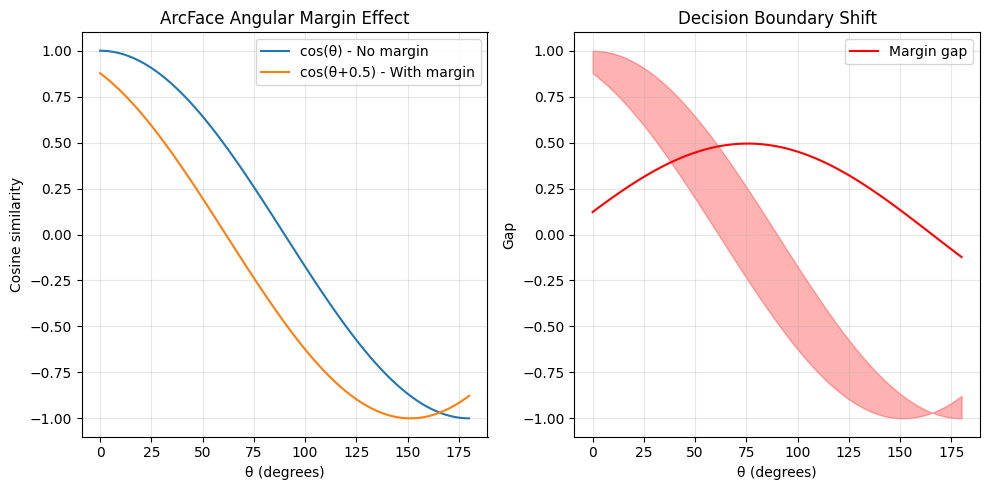

In [19]:
# Visualize margin effect
theta = np.linspace(0, np.pi, 100)
margin = 0.5

cos_theta = np.cos(theta)
cos_theta_margin = np.cos(theta + margin)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(np.degrees(theta), cos_theta, label='cos(θ) - No margin')
plt.plot(np.degrees(theta), cos_theta_margin, label=f'cos(θ+{margin}) - With margin')
plt.xlabel('θ (degrees)')
plt.ylabel('Cosine similarity')
plt.title('ArcFace Angular Margin Effect')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.fill_between(np.degrees(theta), cos_theta, cos_theta_margin, alpha=0.3, color='red')
plt.plot(np.degrees(theta), cos_theta - cos_theta_margin, color='red', label='Margin gap')
plt.xlabel('θ (degrees)')
plt.ylabel('Gap')
plt.title('Decision Boundary Shift')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

# Create directory if it doesn't exist
(PROJECT_ROOT / 'docs' / 'screenshots').mkdir(parents=True, exist_ok=True)

# Save and show the plot
plt.savefig(PROJECT_ROOT / 'docs' / 'screenshots' / 'arcface_margin.png', dpi=150)
plt.show()

## 4. Complete Model

In [20]:
class MobileArcFaceModel(nn.Module):
    """
    Complete Face Recognition Model.

    Combines MobileFaceNet backbone with ArcFace head for training.
    During inference, only the backbone is used to extract embeddings.
    """
    def __init__(self, num_classes, embedding_dim=512, scale=64.0, margin=0.5):
        super().__init__()
        self.backbone = MobileFaceNet(embedding_dim)
        self.head = ArcFace(embedding_dim, num_classes, scale, margin)

    def forward(self, x, labels=None):
        """
        Args:
            x: Input images [batch, 3, 112, 112]
            labels: Class labels (only needed for training)

        Returns:
            If labels provided: Logits for cross-entropy loss
            If no labels: Normalized embeddings for inference
        """
        embeddings = self.backbone(x)

        if labels is not None:
            return self.head(embeddings, labels)
        return embeddings

    def get_embedding(self, x):
        """Extract embedding for inference."""
        with torch.no_grad():
            return self.backbone(x)

print("✅ MobileArcFaceModel defined")

✅ MobileArcFaceModel defined


In [21]:
# Full model analysis
num_classes = 8631  # VGGFace2 112x112 identities
full_model = MobileArcFaceModel(num_classes=num_classes)

# Parameter breakdown
backbone_params = sum(p.numel() for p in full_model.backbone.parameters())
head_params = sum(p.numel() for p in full_model.head.parameters())
total_params = backbone_params + head_params

print("📊 Full Model Analysis (VGGFace2):")
print("="*50)
print(f"Backbone (MobileFaceNet): {backbone_params:,} params")
print(f"Head (ArcFace):           {head_params:,} params")
print(f"Total:                    {total_params:,} params")
print("="*50)
print(f"\n💡 Note: ArcFace head ({head_params:,}) is only used during training!")
print(f"   The head size depends on num_classes ({num_classes:,})")
print(f"   Deployment size: ~{backbone_params * 4 / 1024 / 1024:.1f} MB (FP32)")
print(f"                    ~{backbone_params * 2 / 1024 / 1024:.1f} MB (FP16)")

📊 Full Model Analysis (VGGFace2):
Backbone (MobileFaceNet): 526,080 params
Head (ArcFace):           4,419,072 params
Total:                    4,945,152 params

💡 Note: ArcFace head (4,419,072) is only used during training!
   The head size depends on num_classes (8,631)
   Deployment size: ~2.0 MB (FP32)
                    ~1.0 MB (FP16)


In [22]:
# Test training forward pass
batch_size = 32
x = torch.randn(batch_size, 3, 112, 112)
labels = torch.randint(0, num_classes, (batch_size,))

# Training mode
full_model.train()
logits = full_model(x, labels)
loss = F.cross_entropy(logits, labels)

print("🔥 Training forward pass:")
print(f"   Input: {x.shape}")
print(f"   Labels: {labels.shape}")
print(f"   Logits: {logits.shape}")
print(f"   Loss: {loss.item():.4f}")

🔥 Training forward pass:
   Input: torch.Size([32, 3, 112, 112])
   Labels: torch.Size([32])
   Logits: torch.Size([32, 8631])
   Loss: 43.6136


In [23]:
# Test inference forward pass
full_model.eval()
with torch.no_grad():
    embeddings = full_model(x)  # No labels = inference mode

print("🔍 Inference forward pass:")
print(f"   Input: {x.shape}")
print(f"   Embeddings: {embeddings.shape}")
print(f"   Embedding norms: {embeddings.norm(dim=1).mean():.4f} (should be ~1.0)")

🔍 Inference forward pass:
   Input: torch.Size([32, 3, 112, 112])
   Embeddings: torch.Size([32, 512])
   Embedding norms: 1.0000 (should be ~1.0)


## 5. Architecture Visualization

In [24]:
# Print layer-by-layer shape
def trace_shapes(model, input_shape=(1, 3, 112, 112)):
    """Trace tensor shapes through the model."""
    x = torch.randn(*input_shape)
    print(f"Input: {list(x.shape)}")
    print("-" * 40)

    x = model.conv1(x)
    print(f"conv1: {list(x.shape)}")

    x = model.dw1(x)
    print(f"dw1: {list(x.shape)}")

    x = model.stage1(x)
    print(f"stage1: {list(x.shape)}")

    x = model.stage2(x)
    print(f"stage2: {list(x.shape)}")

    x = model.stage3(x)
    print(f"stage3: {list(x.shape)}")

    x = model.stage4(x)
    print(f"stage4: {list(x.shape)}")

    x = model.conv_expand(x)
    print(f"conv_expand: {list(x.shape)}")

    x = model.gdc(x)
    print(f"gdc: {list(x.shape)}")

    x = x.view(x.size(0), -1)
    print(f"flatten: {list(x.shape)}")

    x = model.fc(x)
    print(f"fc: {list(x.shape)}")

    x = model.bn_final(x)
    print(f"bn_final: {list(x.shape)}")

    x = F.normalize(x, p=2, dim=1)
    print("-" * 40)
    print(f"Output: {list(x.shape)}")

trace_shapes(model)

Input: [1, 3, 112, 112]
----------------------------------------
conv1: [1, 64, 56, 56]
dw1: [1, 64, 56, 56]
stage1: [1, 64, 28, 28]
stage2: [1, 128, 14, 14]
stage3: [1, 128, 7, 7]
stage4: [1, 128, 7, 7]
conv_expand: [1, 512, 7, 7]
gdc: [1, 512, 1, 1]
flatten: [1, 512]
fc: [1, 512]
bn_final: [1, 512]
----------------------------------------
Output: [1, 512]


## 6. Summary & Next Steps

In [25]:
print(f"""\n📋 Architecture Summary:
{"="*50}

1. MobileFaceNet Backbone:
   - Input: 112 × 112 × 3 RGB image
   - Output: 512-D L2-normalized embedding
   - Parameters: ~1M
   - Key: Depthwise separable convolutions

2. ArcFace Head (Training only):
   - Input: 512-D embedding + label
   - Output: Logits with angular margin
   - Scale: 64.0, Margin: 0.5 rad

3. Training:
   - Loss: Cross-entropy on ArcFace logits
   - Optimizer: SGD with momentum
   - Learning rate: 0.1 with warmup + cosine decay

4. Inference:
   - Only backbone is used
   - Compare embeddings with cosine similarity
   - Threshold: ~0.4-0.5 for verification

{"="*50}

📋 Next Steps:
  1. Run 04_training_optimization.ipynb for training setup
  2. Run 05_model_training.ipynb to train the model
  3. Run 06_model_evaluation.ipynb for benchmarks
""")


📋 Architecture Summary:

1. MobileFaceNet Backbone:
   - Input: 112 × 112 × 3 RGB image
   - Output: 512-D L2-normalized embedding
   - Parameters: ~1M
   - Key: Depthwise separable convolutions

2. ArcFace Head (Training only):
   - Input: 512-D embedding + label
   - Output: Logits with angular margin
   - Scale: 64.0, Margin: 0.5 rad

3. Training:
   - Loss: Cross-entropy on ArcFace logits
   - Optimizer: SGD with momentum
   - Learning rate: 0.1 with warmup + cosine decay

4. Inference:
   - Only backbone is used
   - Compare embeddings with cosine similarity
   - Threshold: ~0.4-0.5 for verification


📋 Next Steps:
  1. Run 04_training_optimization.ipynb for training setup
  2. Run 05_model_training.ipynb to train the model
  3. Run 06_model_evaluation.ipynb for benchmarks

